# Previsão de Vendas Liah v5 — benchmark de modelos, granularidades e BigQuery DataFrames

**O que mudou em relação à v4**
- **Dados direto do BigQuery com `bigframes`** (BigQuery DataFrames): as consultas rodam no BigQuery e as agregações pesadas
  (cubo semanal por produto/marca/canal/UF) também — só o resultado pequeno vem para o notebook. Não precisa mais exportar CSV.
- **Caminho feliz:** todo modelo é comparado com alternativas **mais simples** (ingênuo, "repetir o ano passado", ETS, ARIMA,
  SARIMA, Prophet, ARIMA_PLUS do BigQuery ML, ML de calendário, híbrido e combinação). Fica o **mais simples** cujo erro está
  a no máximo `TOLERANCIA_PARCIMONIA` do melhor.
- **Granularidades:** o mesmo benchmark roda para Total, Canal, Origem 1P/3P, Região, UF, Grupo, Subgrupo, Marca e Produto
  (colunas vindas de `gold_core.dim_liah_produtos`). Quanto mais fino o corte, maior o ruído — o notebook mostra isso em números
  e escolhe o modelo certo para cada nível.
- **Top-down:** para níveis finos (marca/produto), testa também "previsão do grupo × participação", que costuma ser mais estável
  quando há **canibalização** dentro do grupo (estudo completo no notebook `canibalizacao_clusters_liah.ipynb`).
- **Tudo explicável:** tabela de hiperparâmetros de cada modelo, ordens escolhidas pelo auto-ARIMA e uma **"ficha do número"**
  mostrando como cada previsão mensal foi montada (pedidos × ticket + extremos ± correção).
- Mantidos da v4: separação base × pedidos extremos (V1/V2), aprendizado com o histórico de previsões (correção de viés).

**Arquivos necessários na mesma pasta:** `liah_dados.py` e `previsao_modelos.py` (e `historico_previsoes.csv`, se já existir).

> Estimativas estatísticas, sujeitas a validação pela área responsável. Não são metas nem dados oficiais da Tecsa.
> As consultas são **somente leitura**, mas rodam no projeto de **produção**: confira o custo estimado no BigQuery.

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# Instala SÓ o que estiver faltando. Não atualiza bibliotecas que o Colab já traz (numpy, pandas, pyarrow, scikit-learn...):
# atualizar biblioteca já carregada pode derrubar o kernel ("kernel restarted") sem mensagem de erro.
import importlib.util, subprocess, sys
faltam = [p for m, p in {'bigframes': 'bigframes', 'prophet': 'prophet', 'statsmodels': 'statsmodels', 'xgboost': 'xgboost', 'holidays': 'holidays'}.items() if importlib.util.find_spec(m) is None]
if faltam:
    print('Instalando:', faltam)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *faltam], check=True)
else:
    print('Todas as bibliotecas já estão instaladas.')

Todas as bibliotecas já estão instaladas.


In [54]:
import os, json, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ===== EXECUÇÃO =====
MODO = os.environ.get('LIAH_MODO', 'bigquery')   # 'bigquery' = consulta via bigframes | 'offline' = lê PASTA_CACHE (sem custo)
PROJETO_EXECUCAO = 'prj-sbx-data-liah-4956'    # projeto que executa e é FATURADO pelas consultas (sandbox Liah)
LOCAL_BQ = None                # região do BigQuery (ex.: 'US', 'southamerica-east1'); None = padrão
PASTA_DRIVE = '/content/drive/MyDrive/previsao_vendas'   # pasta no Drive com os .py e o histórico (None = enviar arquivos a cada sessão)
PASTA_CACHE = 'cache_dados'    # cópia local de cada consulta (permite reprocessar offline)
REUSAR_CACHE_HORAS = 12         # reaproveita consultas idênticas feitas há menos de 12 h (0 = sempre consultar o BigQuery)
COLUNAS_MANUAIS = {}           # se a detecção errar: {'grupo': 'nome_coluna', 'subgrupo': ..., 'marca': ..., 'uf': ...}
DEDUP_ITENS = False            # True se a Query 3 (validação) mostrar linhas repetidas em fct_liah_pedidos_itens

# ===== PREVISÃO TOTAL (mensal) =====
HORIZONTE_MESES = 6            # meses completos à frente (além do mês corrente)
INICIO_TREINO = '2025-01-01'   # descarta a implantação (2024); modelos sazonais simples ainda olham o ano anterior
DATA_ABERTURA = '2026-05-01'   # abertura ao público (CONFIRMAR) — base da média de pedidos extremos
JANELA_EXTREMOS = 'desde_abertura'   # ou 'ultimos_6m'
N_SIMULACOES = 10000
SEED = 42

# ===== BENCHMARK =====
TOLERANCIA_PARCIMONIA = 0.05   # aceita um modelo mais simples se o erro for até 5% maior que o do melhor
REFERENCIA = 'Sazonal ingênuo' # "repetir o ano passado": todo modelo precisa ganhar dele
USAR_ARIMA_PLUS = True         # ARIMA_PLUS no BigQuery ML (só no modo bigquery)
USAR_TIMESFM = False           # TimesFM via AI.FORECAST (exige permissão de Vertex AI no projeto)

# ===== GRANULARIDADES (séries semanais) =====
METRICA_GRANULAR = 'faturamento'   # 'faturamento' ou 'unidades' (somam certo em qualquer corte; 'pedidos' não)
EXCLUIR_EXTREMOS_GRANULAR = True   # extremos distorcem marca/produto; ficam na V2 do total
ORIGENS_SEMANAIS = [26, 20, 13]    # backtest: semanas antes da última semana completa
SEMANAS_TESTE = 13                 # horizonte do backtest (~3 meses)
HORIZONTE_GRANULAR_MESES = 3
NIVEIS = {                         # nome do nível: colunas do cubo. Pais antes dos filhos.
    'Total': [], 'Canal': ['canal'], 'Origem 1P/3P': ['origem'], 'Região': ['regiao'], 'UF': ['uf'],
    'Grupo': ['grupo'], 'Subgrupo': ['subgrupo'], 'Marca': ['marca'], 'Produto': ['produto_nome'],
}
TOP_SERIES = {'UF': 10, 'Marca': 12, 'Produto': 25, 'Subgrupo': 15}   # demais séries do nível viram 'OUTROS'
HIERARQUIA = {'UF': 'Região', 'Subgrupo': 'Grupo', 'Produto': 'Subgrupo', 'Marca': 'Total'}  # para o top-down
SEMANAS_PARTICIPACAO = 13

# ===== APRENDIZADO COM PREVISÕES ANTERIORES (igual v4) =====
ARQ_HISTORICO = 'historico_previsoes.csv'
USAR_CORRECAO_VIES = True; MIN_MESES_AVALIADOS = 3; JANELA_VIES = 6; LIMITE_CORRECAO = 0.15
VERSAO_MODELO = 'v5'

# ===== SAÍDA PARA O METABASE =====
# Dataset onde gravar as tabelas de resultado. None = só CSV.
# ATENÇÃO: use um dataset de sandbox/analytics revisado por outra pessoa — NUNCA gold_core/silver de produção.
DATASET_SAIDA = None           # ex.: 'prj-sbx-data-liah-4956.previsao_vendas' (dataset criado no sandbox)

## 1. Conexão (bigframes) e detecção das colunas

In [35]:
import os, sys, importlib
if PASTA_DRIVE:
    if not os.path.isdir('/content/drive/MyDrive'):   # monta só se ainda não estiver montado (ex.: pelo ícone do Drive na barra lateral)
        from google.colab import drive
        try:
            drive.mount('/content/drive')
        except ValueError:
            drive.mount('/content/drive', force_remount=True)   # 2ª tentativa limpa uma montagem anterior travada
    os.makedirs(PASTA_DRIVE, exist_ok=True); os.chdir(PASTA_DRIVE)
    print('Usando a pasta', PASTA_DRIVE)

faltando = [a for a in ('liah_dados.py', 'previsao_modelos.py') if not os.path.exists(a)]
if faltando:
    from google.colab import files
    print('Envie os módulos:', faltando); files.upload()
sys.path.insert(0, os.getcwd())
import liah_dados as ld, previsao_modelos as pm
importlib.reload(ld); importlib.reload(pm)

if MODO == 'bigquery':
    try:
        from google.colab import auth
        auth.authenticate_user()     # login Google com acesso ao projeto
    except ImportError:
        pass                         # fora do Colab: usa as credenciais padrão (gcloud auth application-default login)

fonte = ld.Fonte(MODO, PASTA_CACHE, PROJETO_EXECUCAO, LOCAL_BQ, reusar_cache_horas=REUSAR_CACHE_HORAS)
cols = ld.detectar_colunas(fonte, COLUNAS_MANUAIS)
print(f'Modo: {MODO} | consultas executadas e faturadas em: {PROJETO_EXECUCAO} | tabelas lidas de: {ld.PROJETO}')
print('Colunas detectadas nas tabelas:')
display(cols.resumo())

Usando a pasta /content/drive/MyDrive/previsao_vendas


Modo: bigquery | consultas executadas e faturadas em: prj-sbx-data-liah-4956 | tabelas lidas de: prj-data-lakehouse-prd-9459
Colunas detectadas nas tabelas:


,campo,coluna encontrada,tabela
0,produto_id,id,dim_liah_produtos
1,produto_nome,nome,dim_liah_produtos
2,marca,marca,dim_liah_produtos
3,grupo,— não encontrada —,
4,subgrupo,— não encontrada —,
5,produto_atualizacao,data_atualizacao,dim_liah_produtos
6,uf,estado,pedidos


## 2. Dados
- `mensal` e `diaria`: mesmas consultas da v4 (agora com a regra de limpeza num lugar só, em `liah_dados.py`).
- `cubos`: dois cubos semanais já agregados no BigQuery: **produto** (semana × produto × marca/grupo/subgrupo × canal × extremo)
  e **geográfico** (semana × canal × origem × UF/região × extremo). São baixados uma vez; cada granularidade é um `groupby` local.

In [36]:
mensal = fonte.df(ld.sql_mensal(cols, DEDUP_ITENS), 'mensal', datas=('ds', 'ultima_data')).sort_values('ds').set_index('ds')
diaria = fonte.df(ld.sql_diaria(cols, DEDUP_ITENS), 'diaria').sort_values('ds').set_index('ds')
mensal['mes_completo'] = mensal['mes_completo'].astype(str).str.lower().isin(['true', '1', '1.0'])
mensal['fat_extremos'] = mensal['faturamento_extremos'].fillna(0)
mensal['ped_extremos'] = mensal['pedidos_extremos'].fillna(0)
mensal['fat_base'] = mensal['faturamento_total'] - mensal['fat_extremos']
mensal['ticket_base'] = mensal['fat_base'] / (mensal['y_total_pedidos'] - mensal['ped_extremos'])

completos = mensal[mensal['mes_completo']]
ultimo_dia = diaria.index.max()
mes_corrente = ultimo_dia.to_period('M').to_timestamp()
USA_BQ = (MODO == 'bigquery') and USAR_ARIMA_PLUS

# Dois cubos semanais (produto e geográfico), baixados UMA vez e já agregados no BigQuery. Cada granularidade
# vira um groupby local, sem nova leitura das tabelas. Separados para caber na memória do Colab.
cubos = ld.Cubos(fonte, cols, DEDUP_ITENS)
print(f'Meses completos: {completos.index.min():%m/%Y} a {completos.index.max():%m/%Y} | diária até {ultimo_dia:%d/%m/%Y}')
print('Colunas disponíveis para os cortes:', cubos.columns)

cubo geo: 314 linhas, 0.0 MB em memória
cubo produto: 32.862 linhas, 1.5 MB em memória
Meses completos: 03/2024 a 09/2026 | diária até 06/10/2026
Colunas disponíveis para os cortes: ['canal', 'eh_extremo', 'faturamento', 'faturamento_preco_cheio', 'grupo', 'id_produto', 'marca', 'origem', 'pedidos', 'produto_nome', 'regiao', 'semana', 'subgrupo', 'uf', 'unidades']


### 2.1 Diagnóstico: base recorrente × pedidos extremos

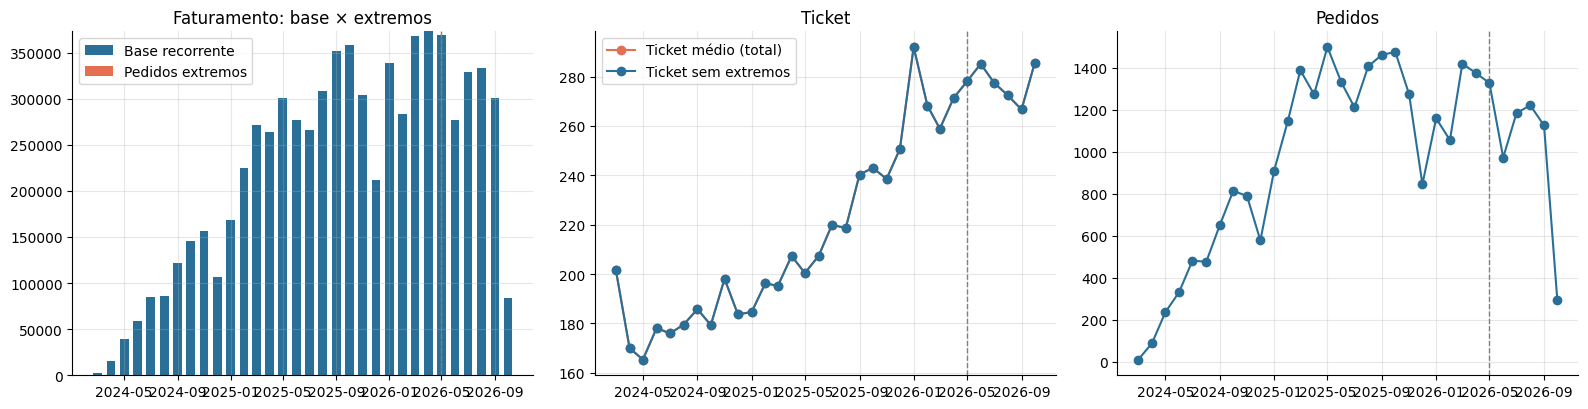

,y_total_pedidos,ped_extremos,faturamento_total,fat_base,fat_extremos,ticket_base
ds,,,,,,
2026-03-01,1420.0,0.0,367582.0,367582.0,0.0,258.9
2026-04-01,1375.0,0.0,373068.5,373068.5,0.0,271.3
2026-05-01,1328.0,0.0,369185.4,369185.4,0.0,278.0
2026-06-01,973.0,0.0,277431.1,277431.1,0.0,285.1
2026-07-01,1185.0,0.0,328863.4,328863.4,0.0,277.5
2026-08-01,1222.0,0.0,332863.3,332863.3,0.0,272.4
2026-09-01,1126.0,0.0,300254.8,300254.8,0.0,266.7
2026-10-01,292.0,0.0,83410.5,83410.5,0.0,285.7


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].bar(mensal.index, mensal['fat_base'], width=20, label='Base recorrente', color='#2a6f97')
axes[0].bar(mensal.index, mensal['fat_extremos'], width=20, bottom=mensal['fat_base'], label='Pedidos extremos', color='#e76f51')
for ax in axes: ax.axvline(pd.Timestamp(DATA_ABERTURA), color='gray', ls='--', lw=1)
axes[0].set_title('Faturamento: base × extremos'); axes[0].legend()
axes[1].plot(mensal.index, mensal['ticket_medio'], marker='o', label='Ticket médio (total)', color='#e76f51')
axes[1].plot(mensal.index, mensal['ticket_base'], marker='o', label='Ticket sem extremos', color='#2a6f97')
axes[1].set_title('Ticket'); axes[1].legend()
axes[2].plot(mensal.index, mensal['y_total_pedidos'], marker='o', color='#2a6f97'); axes[2].set_title('Pedidos')
plt.tight_layout(); plt.show()
display(mensal[['y_total_pedidos', 'ped_extremos', 'faturamento_total', 'fat_base', 'fat_extremos', 'ticket_base']].tail(8).round(1))

## 3. Benchmark do total — do mais simples ao mais complexo
Pedidos **diários** previstos e somados por mês. Backtest com 4 origens (6 meses à frente cada).

| Nível | Modelos | Em uma frase |
|---|---|---|
| 0 | Ingênuo, Média móvel, Sazonal ingênuo | "repete a última semana / a média / o ano passado" |
| 1 | Sazonal × crescimento | "ano passado × ritmo de crescimento recente" |
| 2 | ETS (Holt-Winters), ARIMA | suavização / autorregressivo clássico |
| 3 | SARIMAX calendário, Prophet, ARIMA_PLUS (BigQuery) | sazonalidades + feriados + Black Friday |
| 4 | ML calendário (GB+XGB) | modelo da v4 |
| 5 | Híbrido Prophet+XGB | Prophet faz a base, XGBoost corrige o resíduo |
| 6 | Combinação top-3 | média ponderada pelo erro dos 3 melhores |

**Erro (WAPE)** = soma dos erros absolutos ÷ soma do real. "Errou 5%" = em média, a previsão mensal ficou 5% longe do realizado.

In [38]:
ctx_d = {'freq': 'D', 'feriados': pm.feriados_br(), 'inicio_treino': INICIO_TREINO}
CAT_D = pm.catalogo_padrao('D', SEED, usar_bigquery=USA_BQ, usar_timesfm=USAR_TIMESFM and USA_BQ)

ult_completo = completos.index.max()
FIM_AVAL = ult_completo + pd.offsets.MonthEnd(0)
ORIGENS = [ult_completo - pd.DateOffset(months=k) + pd.offsets.MonthEnd(0) for k in (12, 10, 8, 6)]
serie_ped = diaria['pedidos'].astype(float)

bt_d = pm.backtest({'Total': serie_ped}, CAT_D, ORIGENS, pd.DateOffset(months=HORIZONTE_MESES), ctx_d, fim=FIM_AVAL)
bt_d = pm.adicionar_combinacao(bt_d)
btm_d = pm.mensalizar(bt_d)

tab_d = pm.metricas(btm_d)
ESC_PED, rank_d = pm.escolher(tab_d, CAT_D, TOLERANCIA_PARCIMONIA, REFERENCIA)
print('PEDIDOS — erro mensal por modelo (backtest):')
display(rank_d.round(1))
print(pm.justificar(rank_d, ESC_PED, referencia=REFERENCIA))

por_h = pm.metricas(btm_d, por=('modelo', 'horizonte_mes')).pivot(index='modelo', columns='horizonte_mes', values='WAPE %')
por_h.columns = [f'{c} mês(es)' for c in por_h.columns]
print('\nErro por horizonte (meses à frente):'); display(por_h.loc[rank_d['modelo']].round(1))

Backtest: 1 série(s) × 4 origem(ns) = 4 tarefa(s)
  Ingênuo                       0.0s  (4 previsões)
  Média móvel                   0.0s  (4 previsões)
  Sazonal ingênuo               0.0s  (4 previsões)
  Sazonal × crescimento         0.0s  (4 previsões)
  ETS (Holt-Winters)            0.9s  (4 previsões)
  ARIMA                         8.9s  (4 previsões)
  SARIMAX calendário           18.7s  (4 previsões)
  Prophet                       0.6s  (4 previsões)
  ML calendário (GB+XGB)        2.4s  (4 previsões)
  Híbrido Prophet+XGB           3.1s  (4 previsões)


  ARIMA_PLUS (BigQuery)        39.5s  (4 previsões)
PEDIDOS — erro mensal por modelo (backtest):


,modelo,WAPE %,MAPE %,Viés %,n,complexidade,elegível,ganho vs Sazonal ingênuo (p.p.),escolhido
0,ML calendário (GB+XGB),14.1,15.7,12.6,24.0,4,True,2.1,True
1,Média móvel,15.3,17.3,10.1,24.0,0,False,0.9,False
2,Sazonal ingênuo,16.2,17.1,-1.5,24.0,0,False,0.0,False
3,Ingênuo,17.9,20.0,13.9,24.0,0,False,-1.7,False
4,ETS (Holt-Winters),19.3,21.4,13.3,24.0,2,False,-3.1,False
5,ARIMA,20.0,21.7,12.8,24.0,2,False,-3.8,False
6,Combinação top-3,20.0,21.9,14.4,24.0,6,False,-3.8,False
7,Híbrido Prophet+XGB,21.8,23.5,9.3,24.0,5,False,-5.6,False
8,Prophet,22.2,24.3,9.2,24.0,3,False,-6.0,False
9,ARIMA_PLUS (BigQuery),32.3,35.5,29.5,24.0,3,False,-16.1,False


Escolhido: ML calendário (GB+XGB) (erro 14.1%). Erra 2.1 p.p. menos que "Sazonal ingênuo".

Erro por horizonte (meses à frente):


,1 mês(es),2 mês(es),3 mês(es),4 mês(es),5 mês(es),6 mês(es)
modelo,,,,,,
ML calendário (GB+XGB),12.4,7.6,26.5,6.7,19.1,14.8
Média móvel,12.0,12.1,32.5,14.7,16.0,6.8
Sazonal ingênuo,24.8,17.2,20.7,8.2,17.2,10.3
Ingênuo,14.5,11.3,31.7,16.4,22.8,13.0
ETS (Holt-Winters),15.0,14.3,37.8,19.8,20.0,11.4
ARIMA,16.3,15.0,36.0,20.5,22.2,12.2
Combinação top-3,14.8,14.1,37.1,15.7,21.7,19.2
Híbrido Prophet+XGB,15.7,13.3,41.3,15.8,19.3,28.1
Prophet,17.5,15.8,42.5,21.1,17.2,21.9


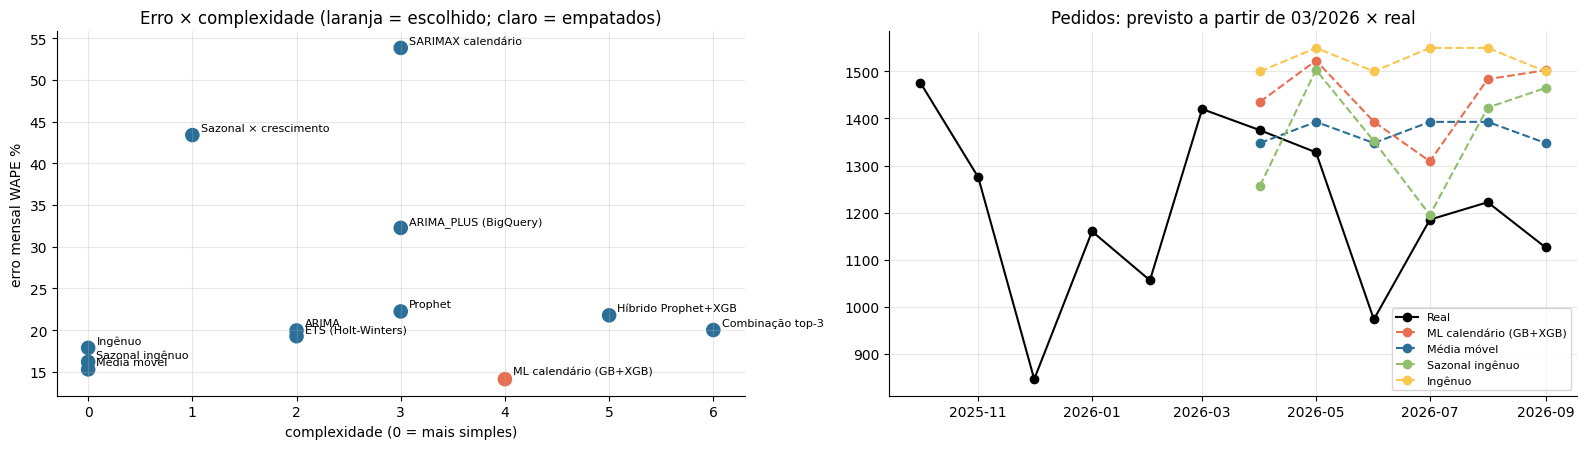

In [39]:
# Gráfico: erro × complexidade (o "caminho feliz" em uma imagem)
r = rank_d.copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
ax = axes[0]
cores = np.where(r['escolhido'], '#e76f51', np.where(r['elegível'], '#f4a261', '#2a6f97'))
ax.scatter(r['complexidade'], r['WAPE %'], s=90, c=cores)
for _, x in r.iterrows():
    ax.annotate(x['modelo'], (x['complexidade'], x['WAPE %']), textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('complexidade (0 = mais simples)'); ax.set_ylabel('erro mensal WAPE %')
ax.set_title('Erro × complexidade (laranja = escolhido; claro = empatados)')
ax = axes[1]
o = ORIGENS[-1]
real = completos.loc[ORIGENS[0]:, 'y_total_pedidos']
ax.plot(real.index, real.values, 'o-', color='black', label='Real')
for mdl, cor in zip(rank_d['modelo'].head(4), ['#e76f51', '#2a6f97', '#90be6d', '#f9c74f']):
    x = btm_d[(btm_d.modelo == mdl) & (btm_d.origem == o)]
    ax.plot(x['mes'], x['previsto'], 'o--', color=cor, label=mdl)
ax.set_title(f'Pedidos: previsto a partir de {o:%m/%Y} × real'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.1 Ticket médio sem extremos
Mesma lógica: métodos simples (média 3m, média 6m) contra Holt amortecido. Faturamento base = pedidos × ticket.

In [40]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def prever_ticket(serie, h):
    s = serie.dropna()
    return {'Média 3m': np.repeat(s.iloc[-3:].mean(), h), 'Média 6m': np.repeat(s.iloc[-6:].mean(), h),
            'Holt amortecido': np.exp(ExponentialSmoothing(np.log(s.values), trend='add', damped_trend=True).fit().forecast(h))}

linhas = []
for o in ORIGENS:
    meses_o = btm_d[(btm_d.origem == o) & (btm_d.modelo == ESC_PED)]['mes']
    tks = prever_ticket(completos.loc[INICIO_TREINO:o, 'ticket_base'], len(meses_o))
    for i, m in enumerate(meses_o):
        linhas.append({'origem': o, 'mes': m, 'tk_real': completos.loc[m, 'ticket_base'], **{k: v[i] for k, v in tks.items()}})
bt_tk = pd.DataFrame(linhas)
aval_tk = pd.Series({k: (np.abs(bt_tk[k] / bt_tk['tk_real'] - 1)).mean() * 100 for k in ('Média 3m', 'Média 6m', 'Holt amortecido')}).sort_values()
display(aval_tk.round(1).rename('erro médio %').to_frame())
# caminho feliz também aqui: Holt só se ganhar das médias com folga
simples = aval_tk[['Média 3m', 'Média 6m']].min()
MET_TICKET = aval_tk.index[0] if aval_tk.iloc[0] < simples * (1 - TOLERANCIA_PARCIMONIA) else aval_tk[['Média 3m', 'Média 6m']].idxmin()
print('Método de ticket escolhido:', MET_TICKET)

# erro do faturamento base (pedidos do modelo escolhido × ticket), usado na faixa da previsão
fb = btm_d[btm_d.modelo == ESC_PED].merge(bt_tk[['origem', 'mes', MET_TICKET]], on=['origem', 'mes'])
fb['fb_prev'] = fb['previsto'] * fb[MET_TICKET]
fb['fb_real'] = fb['mes'].map(completos['fat_base'])
fb['erro_fb'] = np.abs(fb['fb_prev'] / fb['fb_real'] - 1)
print(f"Faturamento base — erro médio: {fb['erro_fb'].mean() * 100:.1f}%")

,erro médio %
Holt amortecido,6.1
Média 3m,7.3
Média 6m,11.7


Método de ticket escolhido: Holt amortecido
Faturamento base — erro médio: 19.6%


## 4. Benchmark por granularidade (séries semanais)
Para cada nível (canal, região, UF, grupo, subgrupo, marca, produto) o mesmo catálogo de modelos é testado.
Cada série do nível é um `groupby` do cubo (local, sem nova consulta); as séries pequenas do nível são somadas em
`OUTROS`, para que a soma do nível continue batendo com o total.

Leitura: **quanto mais fino o corte, maior o erro** (mais ruído). Por isso o modelo que vence no total nem sempre vence na marca —
e às vezes o melhor para a marca é prever o grupo e dividir pela participação (top-down).

In [41]:
METRICA = METRICA_GRANULAR
ultima_sem = ld.ultima_semana_completa(ultimo_dia)
semanas = pd.date_range(pd.Timestamp(INICIO_TREINO) - pd.DateOffset(years=1), ultima_sem, freq='W-MON')

def series_do_nivel(nivel, dims):
    """groupby local no cubo (sem nova consulta) -> {serie: pd.Series semanal}."""
    g = cubos.agregar(dims, [METRICA], EXCLUIR_EXTREMOS_GRANULAR)
    g['semana'] = ld._sem_fuso(g['semana'])
    g = g[g['semana'] <= ultima_sem]
    g['serie'] = g[dims].astype(str).agg(' | '.join, axis=1) if dims else 'Total'
    piv = g.pivot_table(index='semana', columns='serie', values=METRICA, aggfunc='sum').reindex(semanas).fillna(0)
    n = TOP_SERIES.get(nivel)
    recentes = piv.iloc[-26:].sum().sort_values(ascending=False)
    if n and len(recentes) > n:
        manter = list(recentes.index[:n])
        piv = piv[manter].assign(OUTROS=piv.drop(columns=manter).sum(axis=1))
    piv = piv.loc[:, piv.iloc[-26:].sum() > 0]
    return {c: piv[c].astype(float) for c in piv.columns}, g

SERIES, BRUTO = {}, {}
for nivel, dims in NIVEIS.items():
    if dims and all(d not in cubos.columns for d in dims):
        continue
    s, g = series_do_nivel(nivel, dims)
    validas = [k for k in s if not k.startswith(('SEM_INFO', 'SEM_GRUPO', 'SEM_SUBGRUPO', 'SEM_MARCA')) or k == 'Total']
    if dims and len(validas) < 2:
        print(f'{nivel}: pulado (coluna sem informação na base)'); continue
    SERIES[nivel], BRUTO[nivel] = s, g
    print(f'{nivel:<14} {len(s):>3} séries')

Total            1 séries
Canal            2 séries
Origem 1P/3P     3 séries
Região           2 séries
UF               3 séries
Grupo: pulado (coluna sem informação na base)
Subgrupo: pulado (coluna sem informação na base)
Marca           13 séries
Produto         26 séries


In [42]:
ctx_w = {'freq': 'W', 'feriados': pm.feriados_br(), 'inicio_treino': INICIO_TREINO}
CAT_W = pm.catalogo_padrao('W', SEED, usar_bigquery=USA_BQ, usar_timesfm=USAR_TIMESFM and USA_BQ)
ORIGENS_W = [ultima_sem - pd.Timedelta(weeks=k) for k in ORIGENS_SEMANAIS]

def mapa_pai(nivel, pai):
    """série filho -> série pai (pela maior participação no cubo)."""
    if pai == 'Total':
        return {k: 'Total' for k in SERIES[nivel] if k != 'OUTROS'}
    df = BRUTO[nivel].copy()
    dims_f, dims_p = NIVEIS[nivel], NIVEIS[pai]
    if not set(dims_p) <= set(df.columns):
        g = cubos.agregar(dims_f + dims_p, [METRICA], EXCLUIR_EXTREMOS_GRANULAR, com_semana=False)
    else:
        g = df.groupby(dims_f + dims_p, as_index=False)[METRICA].sum()
    g['f'] = g[dims_f].astype(str).agg(' | '.join, axis=1); g['p'] = g[dims_p].astype(str).agg(' | '.join, axis=1)
    g = g.sort_values(METRICA).drop_duplicates('f', keep='last')
    return {f: p for f, p in zip(g['f'], g['p']) if f in SERIES[nivel] and p in SERIES[pai]}

BT_W, RANK_W, ESC_W, PAI_DE = {}, {}, {}, {}
for nivel, series in SERIES.items():
    print(f'\n=== {nivel} ===')
    bt = pm.backtest(series, CAT_W, ORIGENS_W, pd.Timedelta(weeks=SEMANAS_TESTE), ctx_w, fim=ultima_sem, min_hist=26)
    bt = pm.adicionar_combinacao(bt)
    pai = HIERARQUIA.get(nivel)
    if pai in ESC_W:
        PAI_DE[nivel] = mapa_pai(nivel, pai)
        modelo_pai = {s: ESC_W[pai] for s in SERIES[pai]}
        bt = pm.adicionar_top_down(bt, BT_W[pai], series, SERIES[pai], PAI_DE[nivel], modelo_pai, SEMANAS_PARTICIPACAO)
    BT_W[nivel] = bt
    tab = pm.metricas(pm.mensalizar(bt))
    ESC_W[nivel], RANK_W[nivel] = pm.escolher(tab, CAT_W, TOLERANCIA_PARCIMONIA, REFERENCIA)
    print(pm.justificar(RANK_W[nivel], ESC_W[nivel], referencia=REFERENCIA))


=== Total ===
Backtest: 1 série(s) × 3 origem(ns) = 3 tarefa(s)
  Ingênuo                       0.0s  (3 previsões)
  Média móvel                   0.0s  (3 previsões)
  Sazonal ingênuo               0.0s  (3 previsões)
  Sazonal × crescimento         0.0s  (3 previsões)
  ETS (Holt-Winters)            0.1s  (3 previsões)
  ARIMA                         1.6s  (3 previsões)
  SARIMAX calendário            1.4s  (3 previsões)
  Prophet                       0.8s  (3 previsões)
  ML calendário (GB+XGB)        1.2s  (3 previsões)
  Híbrido Prophet+XGB           1.1s  (3 previsões)


  ARIMA_PLUS (BigQuery)        35.9s  (3 previsões)
Escolhido: SARIMAX calendário (erro 9.0%). Erra 4.7 p.p. menos que "Sazonal ingênuo".

=== Canal ===
Backtest: 2 série(s) × 3 origem(ns) = 3 tarefa(s)
  Ingênuo                       0.0s  (3 previsões)
  Média móvel                   0.0s  (3 previsões)
  Sazonal ingênuo               0.0s  (3 previsões)
  Sazonal × crescimento         0.0s  (3 previsões)
  ETS (Holt-Winters)            0.1s  (3 previsões)
  ARIMA                         1.6s  (3 previsões)
  SARIMAX calendário            1.4s  (3 previsões)
  Prophet                       0.8s  (3 previsões)
  ML calendário (GB+XGB)        1.2s  (3 previsões)
  Híbrido Prophet+XGB           2.2s  (3 previsões)


  ARIMA_PLUS (BigQuery)        38.2s  (3 previsões)
Escolhido: ARIMA (erro 9.6%). Erra 5.5 p.p. menos que "Sazonal ingênuo".

=== Origem 1P/3P ===
Backtest: 3 série(s) × 3 origem(ns) = 5 tarefa(s)
  Ingênuo                       0.0s  (5 previsões)
  Média móvel                   0.0s  (5 previsões)
  Sazonal ingênuo               0.0s  (5 previsões)
  Sazonal × crescimento         0.0s  (5 previsões)
  ETS (Holt-Winters)            0.2s  (5 previsões)
  ARIMA                         4.8s  (5 previsões)
  SARIMAX calendário            2.4s  (5 previsões)
  Prophet                       1.3s  (5 previsões)
  ML calendário (GB+XGB)        1.9s  (5 previsões)
  Híbrido Prophet+XGB           1.8s  (5 previsões)


  ARIMA_PLUS (BigQuery)        35.9s  (5 previsões)
Escolhido: ARIMA (erro 103.9%). Erra 105.7 p.p. menos que "Sazonal ingênuo".

=== Região ===
Backtest: 2 série(s) × 3 origem(ns) = 3 tarefa(s)
  Ingênuo                       0.0s  (3 previsões)
  Média móvel                   0.0s  (3 previsões)
  Sazonal ingênuo               0.0s  (3 previsões)
  Sazonal × crescimento         0.0s  (3 previsões)
  ETS (Holt-Winters)            0.1s  (3 previsões)
  ARIMA                         1.6s  (3 previsões)
  SARIMAX calendário            1.4s  (3 previsões)
  Prophet                       0.9s  (3 previsões)
  ML calendário (GB+XGB)        2.9s  (3 previsões)
  Híbrido Prophet+XGB           1.7s  (3 previsões)


  ARIMA_PLUS (BigQuery)        35.0s  (3 previsões)
Escolhido: SARIMAX calendário (erro 9.0%). Erra 4.7 p.p. menos que "Sazonal ingênuo".

=== UF ===
Backtest: 3 série(s) × 3 origem(ns) = 6 tarefa(s)
  Ingênuo                       0.0s  (6 previsões)
  Média móvel                   0.0s  (6 previsões)
  Sazonal ingênuo               0.0s  (6 previsões)
  Sazonal × crescimento         0.0s  (6 previsões)
  ETS (Holt-Winters)            0.3s  (6 previsões)
  ARIMA                         7.4s  (6 previsões)
  SARIMAX calendário            2.3s  (6 previsões)
  Prophet                       1.6s  (6 previsões)
  ML calendário (GB+XGB)        2.3s  (6 previsões)
  Híbrido Prophet+XGB           2.4s  (6 previsões)


  ARIMA_PLUS (BigQuery)        34.7s  (6 previsões)
Escolhido: Top-down (pai × part.) (erro 9.5%). Erra 4.7 p.p. menos que "Sazonal ingênuo".

=== Marca ===
Backtest: 13 série(s) × 3 origem(ns) = 39 tarefa(s)
  Ingênuo                       0.0s  (39 previsões)
  Média móvel                   0.0s  (39 previsões)
  Sazonal ingênuo               0.1s  (39 previsões)
  Sazonal × crescimento         0.0s  (39 previsões)
  ETS (Holt-Winters)            1.1s  (39 previsões)
  ARIMA                        27.4s  (39 previsões)
  SARIMAX calendário           14.9s  (39 previsões)
  Prophet                      11.9s  (39 previsões)
  ML calendário (GB+XGB)       17.6s  (39 previsões)
  Híbrido Prophet+XGB          16.1s  (39 previsões)


  ARIMA_PLUS (BigQuery)        36.4s  (39 previsões)
Escolhido: Combinação top-3 (erro 18.8%). Erra 12.2 p.p. menos que "Sazonal ingênuo".

=== Produto ===
Backtest: 26 série(s) × 3 origem(ns) = 78 tarefa(s)
  Ingênuo                       0.1s  (78 previsões)
  Média móvel                   0.1s  (78 previsões)
  Sazonal ingênuo               0.1s  (78 previsões)
  Sazonal × crescimento         0.1s  (78 previsões)
  ETS (Holt-Winters)            2.6s  (78 previsões)
  ARIMA                        46.4s  (78 previsões)
  SARIMAX calendário           36.0s  (78 previsões)
  Prophet                      20.2s  (78 previsões)
  ML calendário (GB+XGB)       35.0s  (78 previsões)
  Híbrido Prophet+XGB          29.3s  (78 previsões)


  ARIMA_PLUS (BigQuery)        47.5s  (78 previsões)
Escolhido: ARIMA (erro 20.0%). Erra 7.8 p.p. menos que "Sazonal ingênuo".


,séries,modelo escolhido,erro do escolhido %,erro Sazonal ingênuo %,melhor modelo (sem parcimônia)
Total,1,SARIMAX calendário,9.0,13.7,SARIMAX calendário
Canal,2,ARIMA,9.6,15.1,ARIMA
Origem 1P/3P,3,ARIMA,103.9,209.6,ARIMA
Região,2,SARIMAX calendário,9.0,13.7,SARIMAX calendário
UF,3,Top-down (pai × part.),9.5,14.2,Top-down (pai × part.)
Marca,13,Combinação top-3,18.8,31.0,Combinação top-3
Produto,26,ARIMA,20.0,27.8,ARIMA


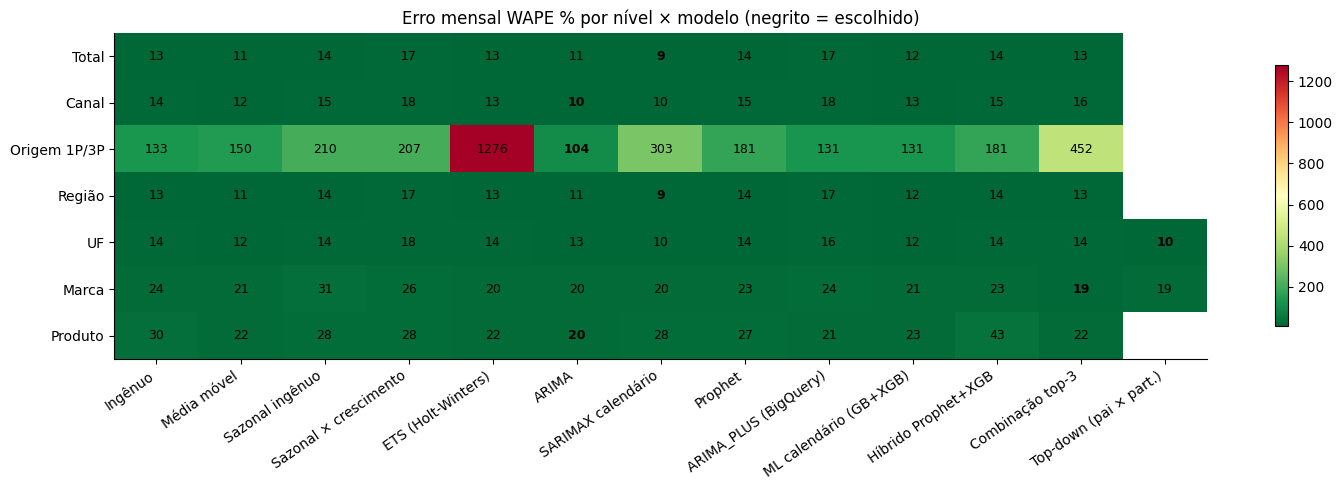

Erro no TOTAL quando se somam as previsões de cada nível (bottom-up):


,Total,Canal,Origem 1P/3P,Região,UF,Marca,Produto
WAPE % do total,9.0,10.6,8.1,9.0,9.0,10.6,11.2


In [43]:
# Quadro-resumo: erro mensal (WAPE %) por nível × modelo — o ruído cresce com a granularidade
quadro = pd.DataFrame({n: r.set_index('modelo')['WAPE %'] for n, r in RANK_W.items()}).T
ordem_modelos = [m.nome for m in sorted(CAT_W, key=lambda m: m.complexidade)] + ['Combinação top-3', 'Top-down (pai × part.)']
quadro = quadro[[c for c in ordem_modelos if c in quadro.columns]]
resumo_niveis = pd.DataFrame({
    'séries': {n: len(SERIES[n]) for n in RANK_W},
    'modelo escolhido': ESC_W,
    'erro do escolhido %': {n: r.loc[r.escolhido, 'WAPE %'].iloc[0] for n, r in RANK_W.items()},
    f'erro {REFERENCIA} %': {n: r.set_index('modelo')['WAPE %'].get(REFERENCIA, np.nan) for n, r in RANK_W.items()},
    'melhor modelo (sem parcimônia)': {n: r.iloc[0]['modelo'] for n, r in RANK_W.items()},
})
display(resumo_niveis.round(1))

fig, ax = plt.subplots(figsize=(15, 0.5 * len(quadro) + 1.5))
im = ax.imshow(quadro.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(quadro.shape[1]), quadro.columns, rotation=35, ha='right'); ax.set_yticks(range(len(quadro)), quadro.index)
for i in range(quadro.shape[0]):
    for j in range(quadro.shape[1]):
        v = quadro.values[i, j]
        if not np.isnan(v):
            negrito = quadro.columns[j] == ESC_W[quadro.index[i]]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9, fontweight='bold' if negrito else 'normal')
ax.grid(False); ax.set_title('Erro mensal WAPE % por nível × modelo (negrito = escolhido)')
plt.colorbar(im, ax=ax, shrink=.8); plt.tight_layout(); plt.show()

# Coerência: somando as previsões do nível, quanto se erra o TOTAL? (bottom-up)
coer = {}
tot_real = pm.mensalizar(BT_W['Total'][BT_W['Total'].modelo == ESC_W['Total']]).groupby(['origem', 'mes'])['real'].sum()
for n, bt in BT_W.items():
    x = pm.mensalizar(bt[bt.modelo == ESC_W[n]]).groupby(['origem', 'mes'])['previsto'].sum()
    j = pd.concat([x, tot_real], axis=1).dropna()
    coer[n] = (j['previsto'] - j['real']).abs().sum() / j['real'].sum() * 100
print('Erro no TOTAL quando se somam as previsões de cada nível (bottom-up):')
display(pd.Series(coer, name='WAPE % do total').round(1).to_frame().T)

## 5. Previsão final do total
- **Pedidos:** modelo escolhido no benchmark (seção 3). Mês corrente = realizado + previsão dos dias restantes.
- **V1 (sem extremos):** pedidos × ticket sem extremos. Faixa = erro do backtest (percentil 80) por horizonte.
- **V2 (com extremos):** V1 + valor médio esperado de extremos (faixa por simulação, como na v4).

In [44]:
fim_prev = mes_corrente + pd.DateOffset(months=HORIZONTE_MESES) + pd.offsets.MonthEnd(0)
datas_fut = pd.date_range(ultimo_dia + pd.Timedelta(days=1), fim_prev)
ped_dia = pm.prever_escolhido(ESC_PED, {'Total': serie_ped}, {'Total': datas_fut}, CAT_D, ctx_d, bt=bt_d)['Total']

corte = pd.Timestamp(mensal.loc[mes_corrente, 'ultima_data']) if mes_corrente in mensal.index else ultimo_dia
ped_mensal = ped_dia[ped_dia.index > corte].resample('MS').sum()
meses = ped_mensal.index
tk_prev = pd.Series(prever_ticket(completos.loc[INICIO_TREINO:, 'ticket_base'], len(meses))[MET_TICKET], index=meses)
fat_base = ped_mensal * tk_prev
if mes_corrente in mensal.index:
    ped_mensal.loc[mes_corrente] += mensal.loc[mes_corrente, 'y_total_pedidos']
    fat_base.loc[mes_corrente] += mensal.loc[mes_corrente, 'fat_base']
fb['h'] = fb['horizonte_mes']
q_h = fb.groupby('h')['erro_fb'].quantile(0.8)
fator = np.array([q_h.get(min(max(i, q_h.index.min()), q_h.index.max())) for i in range(len(meses))])
frac_rest = (mes_corrente + pd.offsets.MonthEnd(0) - corte).days / mes_corrente.days_in_month
fator[0] *= frac_rest

hist_ext = mensal.loc[pd.Timestamp(DATA_ABERTURA):, 'fat_extremos'] if JANELA_EXTREMOS == 'desde_abertura' else mensal['fat_extremos'].iloc[-6:]
rng = np.random.default_rng(SEED)
sims = rng.choice(hist_ext.values, size=(N_SIMULACOES, len(meses)))
ext_media = np.repeat(hist_ext.mean(), len(meses))
ext_p10, ext_p90 = np.quantile(sims, 0.1, axis=0), np.quantile(sims, 0.9, axis=0)
if mes_corrente in mensal.index:
    real_ext = mensal.loc[mes_corrente, 'fat_extremos']
    ext_media[0] = real_ext + ext_media[0] * frac_rest
    ext_p10[0] = real_ext + ext_p10[0] * frac_rest; ext_p90[0] = real_ext + ext_p90[0] * frac_rest

prev = pd.DataFrame({
    'Pedidos previstos': ped_mensal,
    'Pedidos mesmo mês ano ant.': [mensal['y_total_pedidos'].get(m - pd.DateOffset(years=1), np.nan) for m in meses],
    'Ticket base previsto': tk_prev,
    'V1 sem extremos': fat_base, 'V1 mín': fat_base * (1 - fator), 'V1 máx': fat_base * (1 + fator),
    'Extremos esperado': ext_media, 'Extremos p10': ext_p10, 'Extremos p90': ext_p90}, index=meses)
fmt = lambda df: df.set_axis(df.index.strftime('%m/%Y')).round(0)
print(f'Modelo de pedidos: {ESC_PED} | ticket: {MET_TICKET} (antes da correção pelo histórico)')
display(fmt(prev[['Pedidos previstos', 'Pedidos mesmo mês ano ant.', 'Ticket base previsto', 'V1 sem extremos', 'Extremos esperado']]))

Modelo de pedidos: ML calendário (GB+XGB) | ticket: Holt amortecido (antes da correção pelo histórico)


,Pedidos previstos,Pedidos mesmo mês ano ant.,Ticket base previsto,V1 sem extremos,Extremos esperado
ds,,,,,
10/2026,1339.0,1476.0,287.0,383758.0,0.0
11/2026,1088.0,1275.0,289.0,314720.0,0.0
12/2026,882.0,846.0,292.0,257100.0,0.0
01/2027,985.0,1160.0,294.0,289450.0,0.0
02/2027,1038.0,1056.0,296.0,307067.0,0.0
03/2027,1456.0,1420.0,298.0,433381.0,0.0
04/2027,1382.0,1375.0,299.0,413926.0,0.0


### 5.1 Aprendizado com as previsões anteriores (igual v4)
Compara previsões registradas com o realizado nos meses fechados; se o modelo erra sempre para o mesmo lado, corrige
na proporção do viés (limitado a ±`LIMITE_CORRECAO`). O histórico agora guarda também **qual modelo** gerou cada previsão.

In [45]:
DATA_BASE = pd.Timestamp(corte).normalize()
horizonte = pd.Series([(m.year - mes_corrente.year) * 12 + m.month - mes_corrente.month for m in prev.index], index=prev.index)
prev_bruto = prev.copy()

if os.path.exists(ARQ_HISTORICO):
    hist = pd.read_csv(ARQ_HISTORICO)
    hist['data_base'] = pd.to_datetime(hist['data_base']); hist['mes_alvo'] = pd.to_datetime(hist['mes_alvo'])
    hist['data_execucao'] = pd.to_datetime(hist['data_execucao'].astype(str).str[:10])
    if 'modelo_pedidos' not in hist.columns:
        hist['modelo_pedidos'] = np.where(hist['versao'].eq('v4'), 'ML calendário (GB+XGB)', '')
    n_antes = hist['data_base'].nunique()
    hist = hist[hist['data_base'] != DATA_BASE]
    print(f'Histórico: {n_antes} rodada(s)' + (' — a rodada desta data será substituída' if hist['data_base'].nunique() < n_antes else ''))
else:
    hist = pd.DataFrame(); print('Sem histórico: primeira rodada registrada.')

av = pd.DataFrame()
if not hist.empty:
    real = completos[['y_total_pedidos', 'fat_base']].rename(columns={'y_total_pedidos': 'ped_real', 'fat_base': 'fat_real'})
    av = hist.merge(real, left_on='mes_alvo', right_index=True, how='inner')
    av = av[(av['mes_alvo'] < mes_corrente) & (av['data_base'] < av['mes_alvo'] + pd.offsets.MonthEnd(0))]
    av['erro_ped'] = av['ped_prev_bruto'] / av['ped_real'] - 1
    av['erro_fat'] = av['fat_prev_bruto'] / av['fat_real'] - 1

if av.empty:
    print('Nenhum mês fechado com previsão registrada para comparar.')
else:
    display(av.groupby('horizonte').agg(avaliacoes=('mes_alvo', 'count'),
            vies_pedidos_pct=('erro_ped', lambda x: x.mean() * 100), erro_pedidos_pct=('erro_ped', lambda x: x.abs().mean() * 100),
            vies_fat_pct=('erro_fat', lambda x: x.mean() * 100), erro_fat_pct=('erro_fat', lambda x: x.abs().mean() * 100)).round(1))

def calc_vies(col):
    a = av[av['horizonte'] >= 1] if not av.empty else av
    if a.empty or a['mes_alvo'].nunique() < MIN_MESES_AVALIADOS:
        return 1.0, np.nan, (0 if a.empty else a['mes_alvo'].nunique())
    meses_rec = sorted(a['mes_alvo'].unique())[-JANELA_VIES:]
    vies = a[a['mes_alvo'].isin(meses_rec)][col].mean()
    return float(np.clip(1 / (1 + vies), 1 - LIMITE_CORRECAO, 1 + LIMITE_CORRECAO)), vies, len(meses_rec)

f_ped, v_ped, n_ped = calc_vies('erro_ped'); f_fat, v_fat, n_fat = calc_vies('erro_fat')
if not USAR_CORRECAO_VIES: f_ped = f_fat = 1.0
futuro = horizonte >= 1
print(f'Correção de viés: pedidos ×{f_ped:.3f} | faturamento ×{f_fat:.3f}' +
      ('' if not np.isnan(v_fat) else f' (ainda não aplicada: {n_fat} de {MIN_MESES_AVALIADOS} meses avaliados)'))

prev.loc[futuro, 'Pedidos previstos'] *= f_ped
for c in ('V1 sem extremos', 'V1 mín', 'V1 máx'):
    prev.loc[futuro, c] *= f_fat
if not av.empty:
    q_real = av.groupby('horizonte')['erro_fat'].agg(lambda x: np.quantile(np.abs(x), 0.8) if len(x) >= MIN_MESES_AVALIADOS else np.nan)
    for m in prev.index[futuro]:
        h = horizonte[m]
        if h in q_real.index and not np.isnan(q_real[h]):
            prev.loc[m, 'V1 mín'] = prev.loc[m, 'V1 sem extremos'] * (1 - q_real[h])
            prev.loc[m, 'V1 máx'] = prev.loc[m, 'V1 sem extremos'] * (1 + q_real[h])
prev['V2 com extremos'] = prev['V1 sem extremos'] + prev['Extremos esperado']
prev['V2 mín'] = prev['V1 mín'] + prev['Extremos p10']; prev['V2 máx'] = prev['V1 máx'] + prev['Extremos p90']
prev['Var. pedidos vs ano ant. %'] = (prev['Pedidos previstos'] / prev['Pedidos mesmo mês ano ant.'] - 1) * 100

rodada = pd.DataFrame({
    'data_base': DATA_BASE, 'data_execucao': pd.Timestamp.now().normalize(), 'versao': VERSAO_MODELO,
    'mes_alvo': prev.index, 'horizonte': horizonte.values,
    'ped_prev_bruto': prev_bruto['Pedidos previstos'].values, 'fat_prev_bruto': prev_bruto['V1 sem extremos'].values,
    'ped_prev_final': prev['Pedidos previstos'].values, 'fat_prev_final': prev['V1 sem extremos'].values,
    'fat_min': prev['V1 mín'].values, 'fat_max': prev['V1 máx'].values, 'fat_v2_final': prev['V2 com extremos'].values,
    'fator_ped': np.where(futuro, f_ped, 1.0), 'fator_fat': np.where(futuro, f_fat, 1.0),
    'modelo_pedidos': ESC_PED, 'metodo_ticket': MET_TICKET})
print('\nPREVISÃO FINAL')
display(fmt(prev[['Pedidos previstos', 'Var. pedidos vs ano ant. %', 'V1 sem extremos', 'V1 mín', 'V1 máx', 'V2 com extremos', 'V2 mín', 'V2 máx']]))

Histórico: 7 rodada(s) — a rodada desta data será substituída


,avaliacoes,vies_pedidos_pct,erro_pedidos_pct,vies_fat_pct,erro_fat_pct
horizonte,,,,,
0,5,-2.1,3.1,-1.6,2.8
1,4,1.8,11.2,9.3,16.2
2,3,-0.1,10.7,10.9,11.6
3,2,2.5,2.5,16.5,16.5
4,1,15.1,15.1,34.9,34.9


Correção de viés: pedidos ×0.974 | faturamento ×0.879

PREVISÃO FINAL


,Pedidos previstos,Var. pedidos vs ano ant. %,V1 sem extremos,V1 mín,V1 máx,V2 com extremos,V2 mín,V2 máx
ds,,,,,,,,
10/2026,1339.0,-9.0,383758.0,314016.0,453501.0,383758.0,314016.0,453501.0
11/2026,1059.0,-17.0,276603.0,224757.0,328448.0,276603.0,224757.0,328448.0
12/2026,858.0,1.0,225962.0,180723.0,271200.0,225962.0,180723.0,271200.0
01/2027,959.0,-17.0,254393.0,143762.0,365024.0,254393.0,143762.0,365024.0
02/2027,1011.0,-4.0,269877.0,229395.0,310358.0,269877.0,229395.0,310358.0
03/2027,1418.0,-0.0,380892.0,241076.0,520709.0,380892.0,241076.0,520709.0
04/2027,1346.0,-2.0,363793.0,241798.0,485789.0,363793.0,241798.0,485789.0


### 5.2 Ficha do número — como cada previsão foi montada
Para apresentar ao negócio: cada linha explica o número em uma frase.

In [46]:
ficha = pd.DataFrame({
    'mes': prev.index, 'pedidos_previstos': prev['Pedidos previstos'].round(0).values,
    'ticket_base': prev['Ticket base previsto'].round(2).values,
    'base_antes_correcao': prev_bruto['V1 sem extremos'].round(0).values,
    'fator_correcao': np.where(futuro, f_fat, 1.0),
    'v1_sem_extremos': prev['V1 sem extremos'].round(0).values, 'v1_min': prev['V1 mín'].round(0).values, 'v1_max': prev['V1 máx'].round(0).values,
    'extremos_esperado': prev['Extremos esperado'].round(0).values,
    'v2_com_extremos': prev['V2 com extremos'].round(0).values, 'v2_min': prev['V2 mín'].round(0).values, 'v2_max': prev['V2 máx'].round(0).values,
    'modelo_pedidos': ESC_PED, 'metodo_ticket': MET_TICKET, 'data_base': DATA_BASE, 'versao': VERSAO_MODELO})
def frase(r):
    br = lambda v: f'R$ {v:,.0f}'.replace(',', '.')
    t = f"{r.mes:%m/%Y}: {r.pedidos_previstos:,.0f} pedidos × ticket {br(r.ticket_base)} ≈ {br(r.base_antes_correcao)}".replace(',', '.')
    if abs(r.fator_correcao - 1) > 1e-6:
        t += f", ajustado em {(r.fator_correcao - 1) * 100:+.1f}% pelo histórico de erros = {br(r.v1_sem_extremos)}"
    t += f" (faixa {br(r.v1_min)} a {br(r.v1_max)}). Com extremos esperados de {br(r.extremos_esperado)}: {br(r.v2_com_extremos)}."
    return t
ficha['explicacao'] = ficha.apply(frase, axis=1)
for t in ficha['explicacao']:
    print('•', t)

• 10/2026: 1.339 pedidos × ticket R$ 287 ≈ R$ 383.758 (faixa R$ 314.016 a R$ 453.501). Com extremos esperados de R$ 0: R$ 383.758.
• 11/2026: 1.059 pedidos × ticket R$ 289 ≈ R$ 314.720, ajustado em -12.1% pelo histórico de erros = R$ 276.603 (faixa R$ 224.757 a R$ 328.448). Com extremos esperados de R$ 0: R$ 276.603.
• 12/2026: 858 pedidos × ticket R$ 292 ≈ R$ 257.100, ajustado em -12.1% pelo histórico de erros = R$ 225.962 (faixa R$ 180.723 a R$ 271.200). Com extremos esperados de R$ 0: R$ 225.962.
• 01/2027: 959 pedidos × ticket R$ 294 ≈ R$ 289.450, ajustado em -12.1% pelo histórico de erros = R$ 254.393 (faixa R$ 143.762 a R$ 365.024). Com extremos esperados de R$ 0: R$ 254.393.
• 02/2027: 1.011 pedidos × ticket R$ 296 ≈ R$ 307.067, ajustado em -12.1% pelo histórico de erros = R$ 269.877 (faixa R$ 229.395 a R$ 310.358). Com extremos esperados de R$ 0: R$ 269.877.
• 03/2027: 1.418 pedidos × ticket R$ 298 ≈ R$ 433.381, ajustado em -12.1% pelo histórico de erros = R$ 380.892 (faixa R$ 

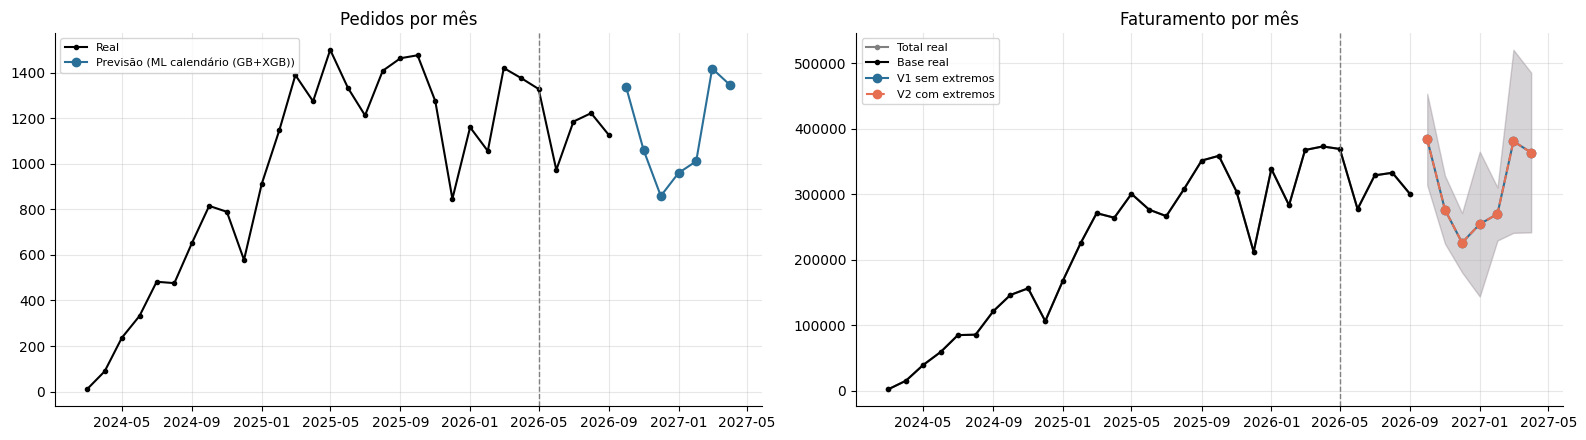

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
ax = axes[0]
ax.plot(completos.index, completos['y_total_pedidos'], 'o-', color='black', ms=3, label='Real')
ax.plot(prev.index, prev['Pedidos previstos'], 'o-', color='#2a6f97', label=f'Previsão ({ESC_PED})')
ax.set_title('Pedidos por mês'); ax.legend(fontsize=8)
ax = axes[1]
ax.plot(completos.index, completos['faturamento_total'], 'o-', color='gray', ms=3, label='Total real')
ax.plot(completos.index, completos['fat_base'], 'o-', color='black', ms=3, label='Base real')
ax.plot(prev.index, prev['V1 sem extremos'], 'o-', color='#2a6f97', label='V1 sem extremos')
ax.fill_between(prev.index, prev['V1 mín'], prev['V1 máx'], color='#2a6f97', alpha=0.2)
ax.plot(prev.index, prev['V2 com extremos'], 'o--', color='#e76f51', label='V2 com extremos')
ax.fill_between(prev.index, prev['V2 mín'], prev['V2 máx'], color='#e76f51', alpha=0.12)
for a in axes: a.axvline(pd.Timestamp(DATA_ABERTURA), color='gray', ls='--', lw=1)
ax.set_title('Faturamento por mês'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Previsão por granularidade
Cada nível usa o modelo escolhido no seu benchmark. Duas colunas:
- `previsto`: previsão direta do nível;
- `previsto_reconciliado`: ajustada proporcionalmente para que **a soma do nível bata com o total** (V1 sem extremos se
  `METRICA_GRANULAR='faturamento'`). Use esta no Metabase quando os números precisarem fechar entre si.

In [48]:
fim_g = mes_corrente + pd.DateOffset(months=HORIZONTE_GRANULAR_MESES) + pd.offsets.MonthEnd(0)
fut_w = pd.date_range(ultima_sem + pd.Timedelta(weeks=1), fim_g, freq='W-MON')
PREV_W = {}
linhas_g = []
for nivel, series in SERIES.items():
    pai = HIERARQUIA.get(nivel)
    p = pm.prever_escolhido(ESC_W[nivel], series, {k: fut_w for k in series}, CAT_W, ctx_w, bt=BT_W[nivel],
                            prev_pai=PREV_W.get(pai), series_pai=SERIES.get(pai), pai_de=PAI_DE.get(nivel),
                            semanas=SEMANAS_PARTICIPACAO)
    if ESC_W[nivel].startswith('Top-down') and 'OUTROS' in series:   # OUTROS não tem pai: completa pelo modelo mais simples elegível
        alt = RANK_W[nivel][RANK_W[nivel]['elegível'] & ~RANK_W[nivel]['modelo'].str.startswith(('Top-down', 'Combinação'))]
        alt = alt.sort_values('complexidade')['modelo'].iloc[0] if len(alt) else REFERENCIA
        p.update(pm.prever_escolhido(alt, {'OUTROS': series['OUTROS']}, {'OUTROS': fut_w}, CAT_W, ctx_w))
    PREV_W[nivel] = p
    faixa = pm.faixa_empirica(pm.mensalizar(BT_W[nivel]), ESC_W[nivel])
    for serie, s in p.items():
        # semana -> dias (1/7 por dia) -> mês: evita jogar a semana inteira no mês da segunda-feira
        diario = pd.Series(np.repeat(s.values / 7, 7), index=pd.DatetimeIndex(np.concatenate([pd.date_range(d, periods=7) for d in s.index])))
        # semana parcial já realizada (após a última semana completa) entra pelo realizado da diária só no total; aqui só futuro
        mens = diario[diario.index <= fim_g].resample('MS').sum()
        for m, v in mens.items():
            h = (m.year - mes_corrente.year) * 12 + m.month - mes_corrente.month
            e = faixa.get(min(max(h, faixa.index.min()), faixa.index.max())) if len(faixa) else np.nan
            linhas_g.append(dict(nivel=nivel, serie=serie, mes=m, previsto=v, previsto_min=v * (1 - e), previsto_max=v * (1 + e),
                                 modelo=ESC_W[nivel]))
prev_g = pd.DataFrame(linhas_g)
# mês corrente: a previsão semanal cobre só as semanas futuras -> soma o realizado do mês até a última semana completa
realizado_mes = {}
for nivel, series in SERIES.items():
    for serie, s in series.items():
        dia = pd.Series(np.repeat(s.values / 7, 7), index=pd.DatetimeIndex(np.concatenate([pd.date_range(d, periods=7) for d in s.index])))
        realizado_mes[(nivel, serie)] = dia[dia.index >= mes_corrente].sum()
cor = prev_g['mes'] == mes_corrente
prev_g.loc[cor, ['previsto', 'previsto_min', 'previsto_max']] = prev_g.loc[cor, ['previsto', 'previsto_min', 'previsto_max']].add(
    prev_g.loc[cor].apply(lambda r: realizado_mes.get((r.nivel, r.serie), 0), axis=1), axis=0)

# reconciliação: soma do nível = total do nível 'Total'
tot = prev_g[prev_g.nivel == 'Total'].set_index('mes')['previsto']
alvo = tot
if METRICA_GRANULAR == 'faturamento':   # alinha com a V1 (já corrigida pelo histórico) quando o mês existir
    v1 = prev['V1 sem extremos']; alvo = tot.where(~tot.index.isin(v1.index), v1.reindex(tot.index))
soma = prev_g.groupby(['nivel', 'mes'])['previsto'].transform('sum')
prev_g['previsto_reconciliado'] = prev_g['previsto'] / soma * prev_g['mes'].map(alvo)
prev_g['participacao_pct'] = prev_g['previsto'] / soma * 100
prev_g['metrica'] = METRICA_GRANULAR; prev_g['data_base'] = DATA_BASE; prev_g['versao'] = VERSAO_MODELO

for nivel in [n for n in ('Canal', 'Grupo', 'Marca') if n in SERIES]:
    t = prev_g[prev_g.nivel == nivel].pivot_table(index='serie', columns='mes', values='previsto_reconciliado')
    t.columns = t.columns.strftime('%m/%Y')
    print(f'\n{nivel} — {METRICA_GRANULAR} previsto (reconciliado com o total):')
    display(t.sort_values(t.columns[-1], ascending=False).round(0))


Canal — faturamento previsto (reconciliado com o total):


mes,10/2026,11/2026,12/2026,01/2027
serie,,,,
COM_NUTRICIONISTA,307788.0,228418.0,207154.0,240735.0
SEM_NUTRICIONISTA,75970.0,48185.0,18808.0,13658.0



Marca — faturamento previsto (reconciliado com o total):


mes,10/2026,11/2026,12/2026,01/2027
serie,,,,
VITAFOR,87948.0,65210.0,57807.0,63228.0
DUX,117213.0,76767.0,54899.0,60736.0
ESSENTIAL,27584.0,23360.0,15201.0,23750.0
OUTROS,37792.0,24571.0,19946.0,23732.0
TRUE SOURCE,21226.0,16651.0,16371.0,17253.0
NUTRIFY,18160.0,14133.0,13628.0,14069.0
EQUALIV,14307.0,10030.0,9062.0,9348.0
CENTRAL NUTRITION,9377.0,9894.0,7848.0,8309.0
PURAVIDA,16508.0,9812.0,7390.0,8091.0


## 7. Hiperparâmetros e escolhas (para ter tudo em mãos)
- Catálogo completo com os parâmetros de cada modelo (diário e semanal).
- Ordens escolhidas automaticamente pelo ARIMA_PLUS (p, d, q, drift, sazonalidades, feriados) e pelo ARIMA local.
- Pesos das combinações e participações usadas no top-down.

In [49]:
hp = pd.concat([pm.tabela_hiperparametros(CAT_D).assign(frequencia='diária (total)'),
                pm.tabela_hiperparametros(CAT_W).assign(frequencia='semanal (granularidades)')])
regras = pd.DataFrame([
    ('Regra', 'TOLERANCIA_PARCIMONIA', TOLERANCIA_PARCIMONIA), ('Regra', 'REFERENCIA', REFERENCIA),
    ('Regra', 'INICIO_TREINO', INICIO_TREINO), ('Regra', 'ORIGENS (total)', [o.strftime('%Y-%m-%d') for o in ORIGENS]),
    ('Regra', 'ORIGENS (semanal)', [o.strftime('%Y-%m-%d') for o in ORIGENS_W]), ('Regra', 'SEMANAS_TESTE', SEMANAS_TESTE),
    ('Regra', 'METRICA_GRANULAR', METRICA_GRANULAR), ('Regra', 'EXCLUIR_EXTREMOS_GRANULAR', EXCLUIR_EXTREMOS_GRANULAR),
    ('Regra', 'TOP_SERIES', TOP_SERIES), ('Regra', 'HIERARQUIA', HIERARQUIA),
    ('Extremos', 'regra', ld.EXTREMO), ('Extremos', 'DATA_ABERTURA', DATA_ABERTURA), ('Extremos', 'JANELA_EXTREMOS', JANELA_EXTREMOS),
    ('Viés', 'USAR_CORRECAO_VIES', USAR_CORRECAO_VIES), ('Viés', 'MIN_MESES_AVALIADOS', MIN_MESES_AVALIADOS),
    ('Viés', 'JANELA_VIES', JANELA_VIES), ('Viés', 'LIMITE_CORRECAO', LIMITE_CORRECAO),
    ('Escolha', 'pedidos (total)', ESC_PED), ('Escolha', 'ticket', MET_TICKET),
    *[('Escolha', f'nível {n}', e) for n, e in ESC_W.items()]], columns=['modelo', 'parametro', 'valor'])
regras['valor'] = regras['valor'].astype(str); regras['frequencia'] = 'geral'
hiperparametros = pd.concat([hp, regras], ignore_index=True).assign(data_base=DATA_BASE, versao=VERSAO_MODELO)
display(hiperparametros[hiperparametros.modelo.isin([ESC_PED, *ESC_W.values(), 'Regra', 'Escolha'])][['frequencia', 'modelo', 'parametro', 'valor']])

diag = {}
for nome, c in (('diária', ctx_d), ('semanal', ctx_w)):
    for k, lst in c.get('diagnostico', {}).items():
        diag[f'{k} ({nome})'] = pd.concat(lst, ignore_index=True)
for k, v in diag.items():
    print(f'\n{k} — ordens escolhidas pelo auto-ARIMA (primeiras linhas):')
    display(v.head(10))
arima_ord = pd.Series(ctx_w.get('ordens_arima', []) + ctx_d.get('ordens_arima', [])).value_counts()
if len(arima_ord):
    print('ARIMA local — ordens (p,d,q) mais escolhidas pelo AIC:'); display(arima_ord.head(8).to_frame('vezes'))
if ctx_w.get('pesos_combinacao') or ctx_d.get('pesos_combinacao'):
    print('Pesos das combinações:', {**ctx_d.get('pesos_combinacao', {}), **ctx_w.get('pesos_combinacao', {})})
falhas = ctx_d.get('falhas', []) + ctx_w.get('falhas', [])
if falhas:
    print(f'\n{len(falhas)} ajuste(s) falharam (o modelo fica sem nota naquela série):'); display(pd.DataFrame(falhas, columns=['modelo', 'tarefa', 'erro']).head(10))

,frequencia,modelo,parametro,valor
12,diária (total),ARIMA,grade,"[(1, 1, 1), (0, 1, 1), (1, 1, 0), (2, 1, 2), (..."
13,diária (total),SARIMAX calendário,ordem,"(1, 1, 1)"
14,diária (total),SARIMAX calendário,sazonal,"(1, 0, 1, 7)"
15,diária (total),SARIMAX calendário,fourier,3
22,diária (total),ML calendário (GB+XGB),tendencia,True
23,diária (total),ML calendário (GB+XGB),meia_vida_dias,180
24,diária (total),ML calendário (GB+XGB),seed,42
25,diária (total),ML calendário (GB+XGB),gb.n_estimators,300
26,diária (total),ML calendário (GB+XGB),gb.max_depth,3
27,diária (total),ML calendário (GB+XGB),gb.learning_rate,0.03



ARIMA_PLUS (diária) — ordens escolhidas pelo auto-ARIMA (primeiras linhas):


,id,non_seasonal_p,non_seasonal_d,non_seasonal_q,has_drift,log_likelihood,AIC,variance,seasonal_periods,has_holiday_effect,has_spikes_and_dips,has_step_changes,error_message
0,1,3,1,0,False,121.23697436124299,-234.47394872248597,0.02823856798796183,WEEKLY,False,False,False,
1,2,2,1,3,False,271.89908425097855,-531.7981685019571,0.014530926047433034,WEEKLY,True,False,False,
2,3,2,1,3,False,245.47628374483708,-478.95256748967415,0.01948960325045128,WEEKLY,True,False,False,
3,0,2,1,3,True,114.41947373266765,-214.8389474653353,0.024767007710287874,WEEKLY,False,False,False,



ARIMA_PLUS (semanal) — ordens escolhidas pelo auto-ARIMA (primeiras linhas):


,id,non_seasonal_p,non_seasonal_d,non_seasonal_q,has_drift,log_likelihood,AIC,variance,seasonal_periods,has_holiday_effect,has_spikes_and_dips,has_step_changes,error_message
0,0,1,1,1,True,28.131335095802356,-48.26267019160471,0.023269279577102307,NO_SEASONALITY,False,True,False,
1,1,1,1,1,True,32.95704639097985,-57.914092781959695,0.021911883854652366,NO_SEASONALITY,False,True,False,
2,2,1,1,1,True,37.11779336685495,-66.2355867337099,0.02151119021011398,NO_SEASONALITY,False,True,False,
3,2,1,1,1,True,37.117720456738006,-66.23544091347601,0.02150678712835617,NO_SEASONALITY,False,True,False,
4,1,1,1,1,True,32.9571135301942,-57.9142270603884,0.02190568417249829,NO_SEASONALITY,False,True,False,
5,0,1,1,1,True,28.131335095239052,-48.262670190478104,0.023269295545485184,NO_SEASONALITY,False,True,False,
6,2,1,1,1,True,28.131335095239052,-48.262670190478104,0.023269295545485184,NO_SEASONALITY,False,True,False,
7,3,1,1,1,True,32.9571135301942,-57.9142270603884,0.02190568417249829,NO_SEASONALITY,False,True,False,
8,1,0,1,0,False,-127.5368900874508,257.0737801749016,1.6076434793771406,NO_SEASONALITY,False,False,False,
9,4,3,2,0,False,-27.108787619121852,62.217575238243704,0.11424080888747815,NO_SEASONALITY,False,True,False,


ARIMA local — ordens (p,d,q) mais escolhidas pelo AIC:


,vezes
"(0, 1, 1)",80
"(1, 0, 1)",48
"(1, 1, 1)",24
"(2, 1, 2)",14
"(2, 0, 1)",12


Pesos das combinações: {'DUX': {'Prophet': 0.34, 'Híbrido Prophet+XGB': 0.338, 'SARIMAX calendário': 0.322}, 'VITAFOR': {'SARIMAX calendário': 0.385, 'ETS (Holt-Winters)': 0.309, 'Média móvel': 0.307}, 'ESSENTIAL': {'SARIMAX calendário': 0.347, 'Sazonal ingênuo': 0.336, 'ARIMA': 0.317}, 'NUTRIFY': {'ETS (Holt-Winters)': 0.336, 'ARIMA': 0.332, 'ARIMA_PLUS (BigQuery)': 0.332}, 'TRUE SOURCE': {'Média móvel': 0.335, 'Ingênuo': 0.333, 'ARIMA_PLUS (BigQuery)': 0.332}, 'EQUALIV': {'ML calendário (GB+XGB)': 0.339, 'ARIMA': 0.332, 'ARIMA_PLUS (BigQuery)': 0.329}, 'PURAVIDA': {'Híbrido Prophet+XGB': 0.375, 'ML calendário (GB+XGB)': 0.319, 'Prophet': 0.306}, 'CAFFEINE ARMY': {'ML calendário (GB+XGB)': 0.362, 'ETS (Holt-Winters)': 0.328, 'ARIMA': 0.31}, 'OCEAN DROP': {'SARIMAX calendário': 0.367, 'ARIMA': 0.325, 'ETS (Holt-Winters)': 0.308}, 'CENTRAL NUTRITION': {'Híbrido Prophet+XGB': 0.39, 'Média móvel': 0.306, 'Prophet': 0.304}, 'ADAPTOGEN': {'ETS (Holt-Winters)': 0.339, 'ARIMA': 0.332, 'ARIMA_

## 8. Exportar (CSV + tabelas para o Metabase) e atualizar o histórico
Tabelas geradas (nomes iguais em CSV e no BigQuery, se `DATASET_SAIDA` estiver preenchido):

| Tabela | Conteúdo | Uso no Metabase |
|---|---|---|
| `liah_previsao_mensal` | ficha do número (V1/V2, faixas, frase explicativa) | cartão principal |
| `liah_previsao_granular` | previsão por nível/série/mês, direta e reconciliada | filtros por canal, marca, UF... |
| `liah_realizado_granular` | realizado mensal por nível/série (últimos 12 meses) | real × previsto |
| `liah_benchmark_modelos` | erro de cada modelo por nível, escolhido e justificativa | "por que este modelo" |
| `liah_hiperparametros` | todos os parâmetros e regras da rodada | auditoria |
| `liah_historico_previsoes` | todas as rodadas (aprendizado) | acurácia ao longo do tempo |

**A cada execução** os arquivos de `saida/` são lidos e atualizados: as rodadas anteriores ficam, e as linhas da mesma
`data_base` são substituídas (rodar de novo no mesmo dia não duplica). `liah_realizado_granular` e o histórico são
sempre regravados inteiros. Para voltar a gravar só a rodada atual, use `MANTER_RODADAS_ANTERIORES = False`.

In [50]:
bench = []
bench.append(rank_d.assign(nivel='Total (pedidos diários)', justificativa=pm.justificar(rank_d, ESC_PED, referencia=REFERENCIA)))
for n, r in RANK_W.items():
    bench.append(r.assign(nivel=n, justificativa=pm.justificar(r, ESC_W[n], referencia=REFERENCIA)))
bench = pd.concat(bench, ignore_index=True).assign(data_base=DATA_BASE, versao=VERSAO_MODELO)
bench.columns = [c.replace(' %', '_pct').replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').lower() for c in bench.columns]

real_g = []
for nivel, series in SERIES.items():
    for serie, s in series.items():
        dia = pd.Series(np.repeat(s.values / 7, 7), index=pd.DatetimeIndex(np.concatenate([pd.date_range(d, periods=7) for d in s.index])))
        mm = dia[(dia.index < mes_corrente) & (dia.index >= mes_corrente - pd.DateOffset(months=12))].resample('MS').sum()
        real_g += [dict(nivel=nivel, serie=serie, mes=m, realizado=v, metrica=METRICA_GRANULAR) for m, v in mm.items()]
real_g = pd.DataFrame(real_g)

hist_novo = pd.concat([hist, rodada], ignore_index=True).sort_values(['data_base', 'mes_alvo'])
saidas = {'liah_previsao_mensal': ficha, 'liah_previsao_granular': prev_g, 'liah_realizado_granular': real_g,
          'liah_benchmark_modelos': bench, 'liah_hiperparametros': hiperparametros, 'liah_historico_previsoes': hist_novo}
if diag:
    saidas['liah_arima_plus_ordens'] = pm.como_texto(pd.concat([v.assign(origem=k) for k, v in diag.items()], ignore_index=True)).assign(data_base=DATA_BASE)

# Cada execução LÊ os arquivos que já estão em saida/ e atualiza: mantém as rodadas anteriores e substitui
# só as linhas da mesma data_base (rodar 2x no mesmo dia não duplica). False = apaga e grava só esta rodada.
MANTER_RODADAS_ANTERIORES = True
SEMPRE_SUBSTITUIR = {'liah_realizado_granular', 'liah_historico_previsoes'}   # já são a foto completa e atual

print('Atualizando saida/:')
finais = {nome: ld.atualizar_saida(df, nome, substituir_tudo=(not MANTER_RODADAS_ANTERIORES) or nome in SEMPRE_SUBSTITUIR)
          for nome, df in saidas.items()}
hist_novo.round(4).to_csv(ARQ_HISTORICO, index=False, date_format='%Y-%m-%d')
hp_json = {'data_base': str(DATA_BASE.date()), 'versao': VERSAO_MODELO, 'escolhas': {'pedidos': ESC_PED, 'ticket': MET_TICKET, **ESC_W},
           'catalogo_diario': {m.nome: m.params for m in CAT_D}, 'catalogo_semanal': {m.nome: m.params for m in CAT_W}}
for arq in ('saida/hiperparametros_rodada.json', f'saida/hiperparametros_{DATA_BASE:%Y-%m-%d}.json'):   # última + uma por rodada
    with open(arq, 'w', encoding='utf-8') as f:
        json.dump(hp_json, f, ensure_ascii=False, indent=1, default=str)
print(f'{ARQ_HISTORICO}: {hist_novo["data_base"].nunique()} rodada(s)')

if DATASET_SAIDA:
    for nome, df in finais.items():   # grava a tabela completa (todas as rodadas) no BigQuery
        fonte.salvar_tabela(df, f'{DATASET_SAIDA}.{nome}')
    print('Tabelas gravadas em', DATASET_SAIDA)
elif not PASTA_DRIVE:
    print(f'IMPORTANTE: guarde {ARQ_HISTORICO} e envie de novo na próxima rodada, senão o aprendizado recomeça do zero.')

Atualizando saida/:
  liah_previsao_mensal.csv: 14 linhas — 1 rodada(s) anterior(es) mantida(s); 7 linha(s) da mesma data substituída(s)
  liah_previsao_granular.csv: 400 linhas — 1 rodada(s) anterior(es) mantida(s); 200 linha(s) da mesma data substituída(s)
  liah_realizado_granular.csv: 600 linhas — substituído pela versão desta rodada
  liah_benchmark_modelos.csv: 196 linhas — 1 rodada(s) anterior(es) mantida(s); 98 linha(s) da mesma data substituída(s)
  liah_hiperparametros.csv: 248 linhas — 1 rodada(s) anterior(es) mantida(s); 124 linha(s) da mesma data substituída(s)
  liah_historico_previsoes.csv: 49 linhas — substituído pela versão desta rodada
  liah_arima_plus_ordens.csv: 290 linhas — 1 rodada(s) anterior(es) mantida(s); 145 linha(s) da mesma data substituída(s)
historico_previsoes.csv: 7 rodada(s)


In [51]:
fonte.resumo_custo()   # consultas feitas no BigQuery × reaproveitadas do cache

Consultas ao BigQuery: 0 [] | reaproveitadas do cache (sem custo): 5 ['schema', 'mensal', 'diaria', 'cubo_geo', 'cubo_produto']
